# Nhiệm vụ 1: Xây dựng mô hình SVM để phân loại các loài hoa cẩm chướng

## 1. Tải thư viện và nạp dữ liệu

In [ ]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Nạp dữ liệu Iris từ Kaggle
df = pd.read_csv('Iris.csv')

# Xem qua dữ liệu
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


## 2. Tiền xử lý dữ liệu

In [2]:
# Loại bỏ cột 'Id' và tách đặc trưng (X) và nhãn (y)
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia dữ liệu thành tập train và tập test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 3. Xây dựng và huấn luyện mô hình SVM

In [3]:
# Khởi tạo và huấn luyện mô hình SVM với kernel tuyến tính
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = svm.predict(X_test)

# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of SVM (Linear Kernel): {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy of SVM (Linear Kernel): 0.97

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



## 4. Thử nghiệm với các kernel khác (RBF và Polynomial)

In [4]:
# SVM với kernel RBF
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy of SVM (RBF Kernel): {accuracy_rbf:.2f}")

# SVM với kernel Polynomial
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy of SVM (Polynomial Kernel): {accuracy_poly:.2f}")

Accuracy of SVM (RBF Kernel): 1.00
Accuracy of SVM (Polynomial Kernel): 0.97


## 5. Vẽ biểu đồ so sánh độ chính xác của các kernel

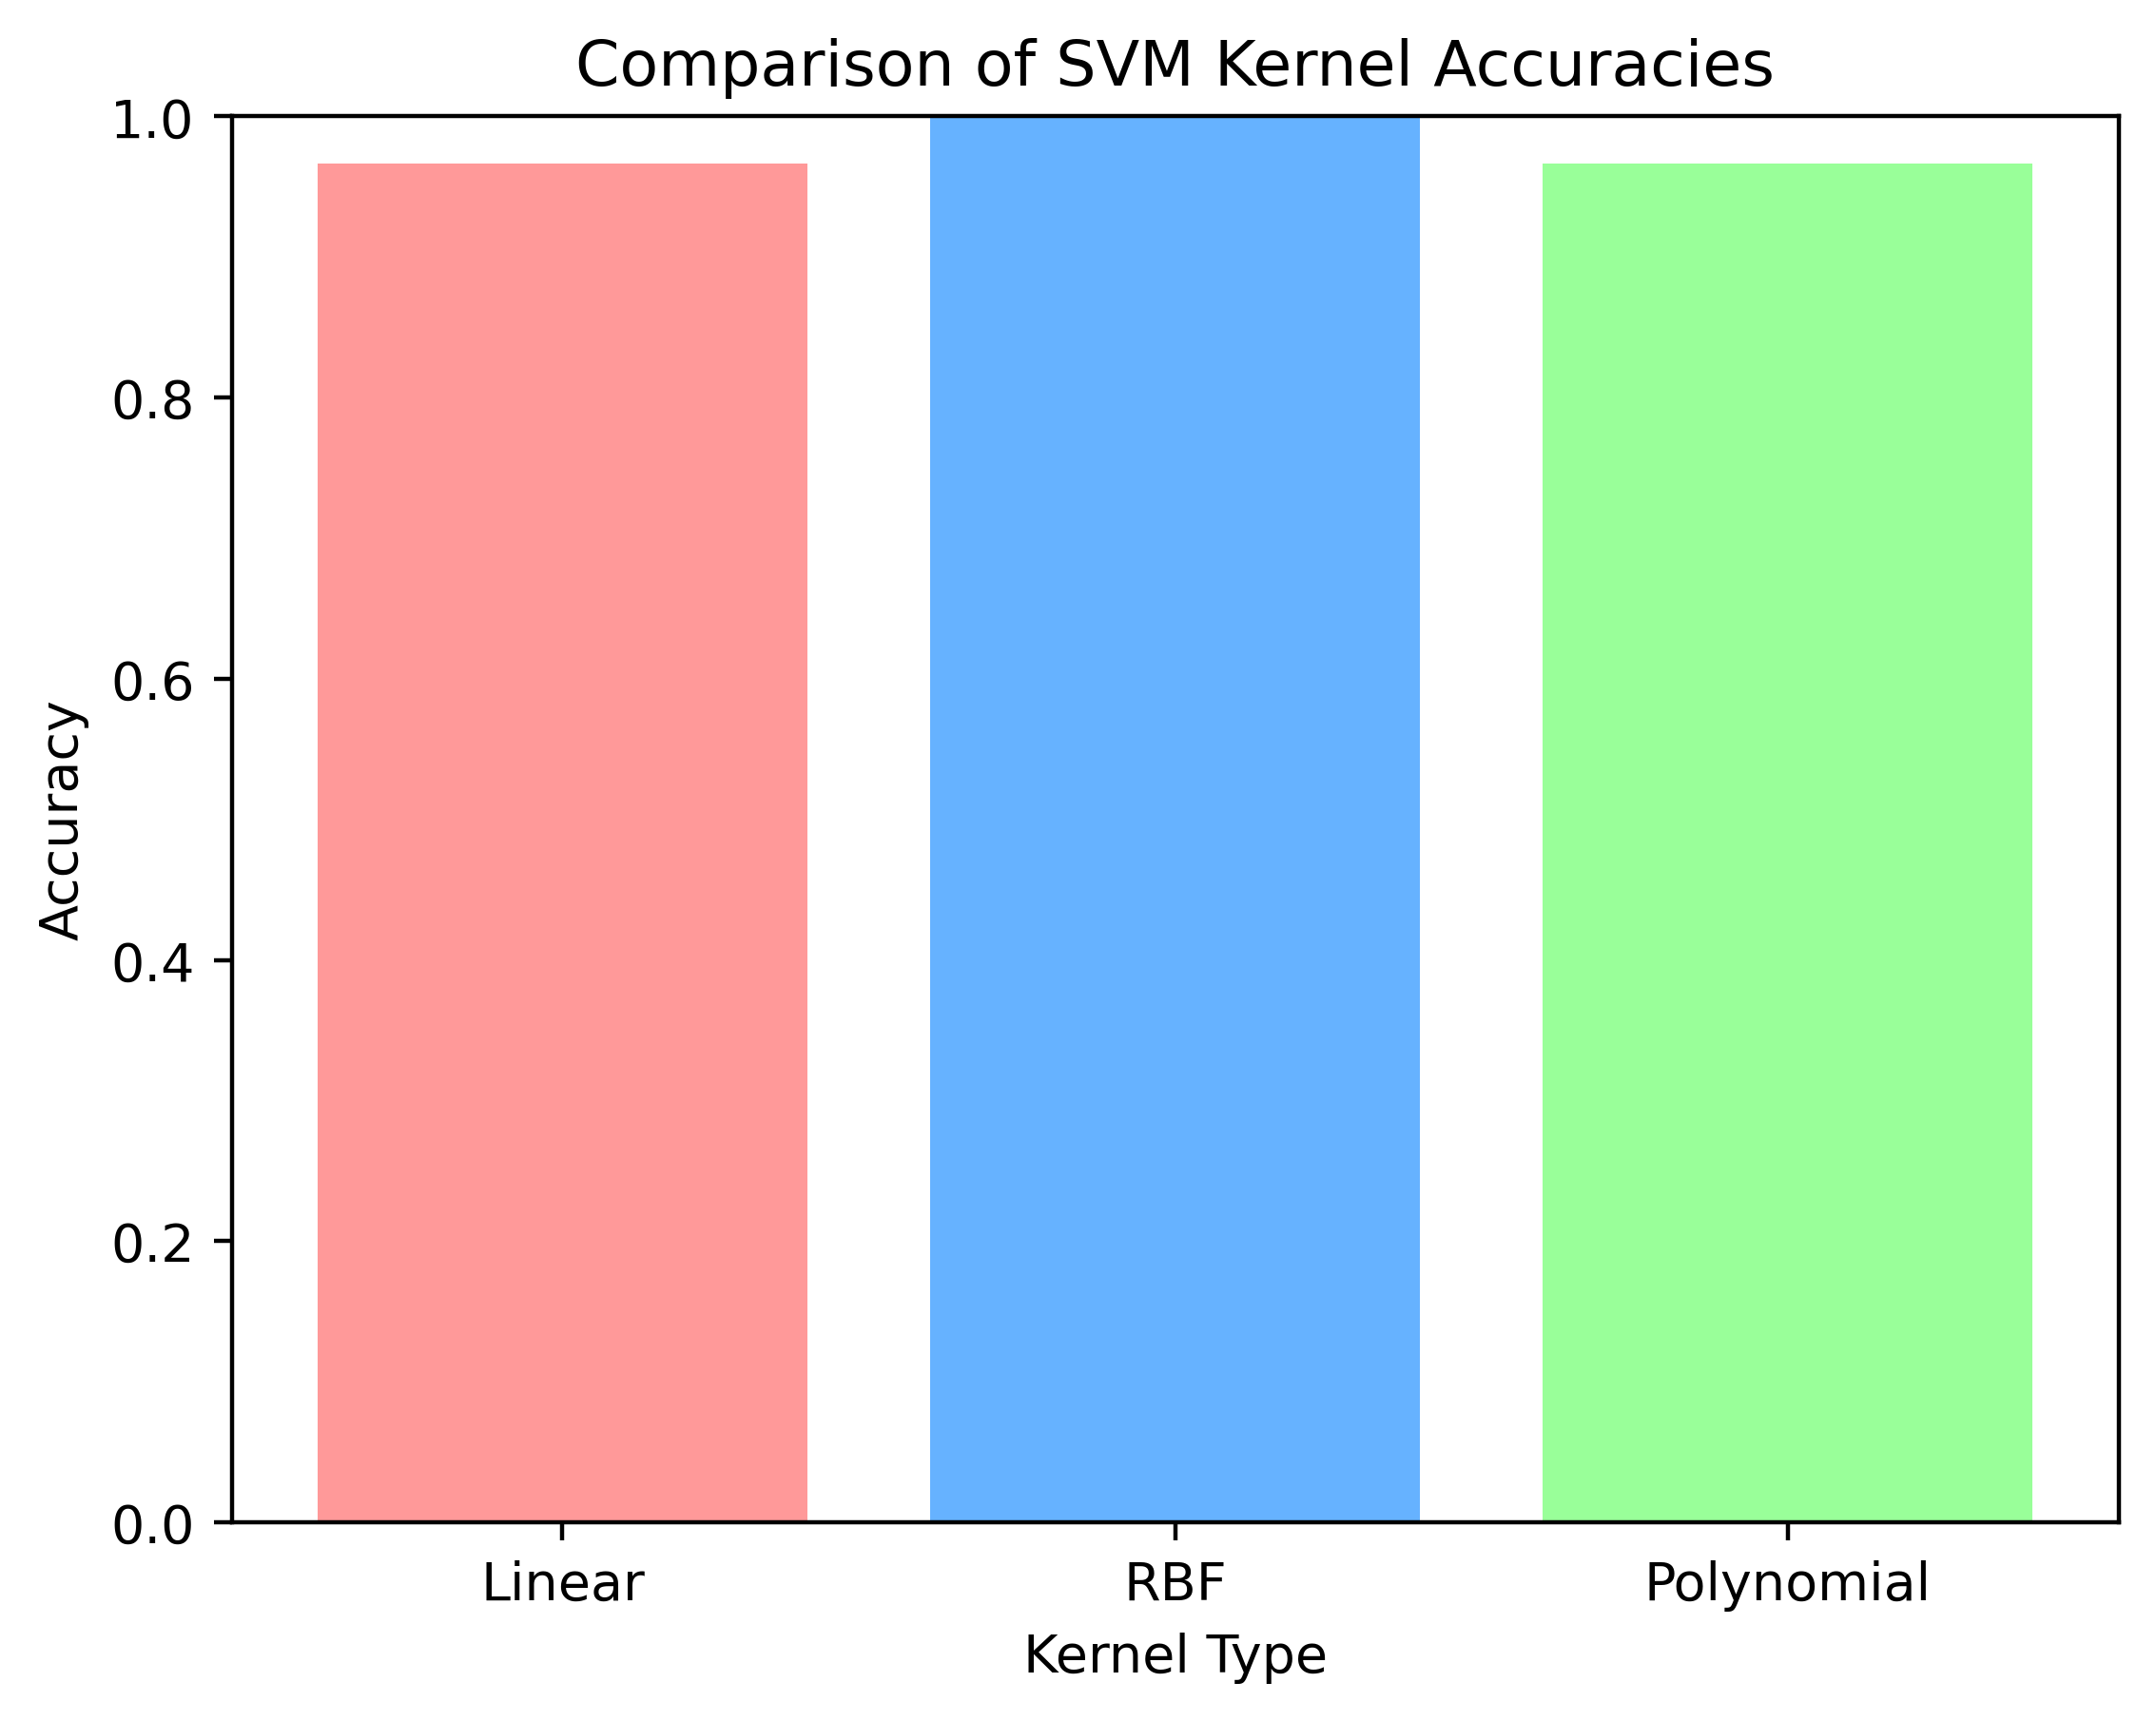

In [5]:
# Dữ liệu để vẽ biểu đồ
kernels = ['Linear', 'RBF', 'Polynomial']
accuracies = [accuracy, accuracy_rbf, accuracy_poly]

# Vẽ biểu đồ cột
plt.bar(kernels, accuracies, color=['#FF9999', '#66B2FF', '#99FF99'])
plt.title('Comparison of SVM Kernel Accuracies')
plt.xlabel('Kernel Type')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Giới hạn trục y từ 0 đến 1
plt.show()